In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
from matplotlib import pyplot as plt


In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
# entendendo a estrutura do dataset

In [4]:
df.shape

(891, 12)

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.isnull().mean().round(2) * 100

PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            20.0
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.0
Embarked        0.0
dtype: float64

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.drop(columns=['Name'], inplace=True)

In [10]:
df = df.rename(columns={'PassengerId':'Id_passageiro', 'Survived':'Sobrevivente', 'Pclass':'Classe', 'Sex':'Sexo', 'Age':'Idade',
                   'SibSp':'Irmaos_conjunges', 'Parch':'Pais_Filhos', 'Ticket':'Bilhete', 'Fare':'Custo_Bilhete', 'Cabin':'Cabine','Embarked':'Porto_embarque'})

In [11]:
df.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df['Sexo'] = df['Sexo'].replace({'male':'Masculino', 'female':'Feminino'})

In [13]:
df['Custo_Bilhete'] = df['Custo_Bilhete'].round(2)

In [14]:
df['Idade'] = df['Idade'].round(0)

In [15]:
map_sexo = {'Masculino':1, 'Feminino':2}

In [16]:
df['Sexo (Nominal)'] = df['Sexo'].map(map_sexo)

In [17]:
map_porto = {'C':1, 'Q':2, 'S':3, 'Nao identificado':4}

In [18]:
df['Porto_embarque (Ordinal)'] = df['Porto_embarque'].map(map_porto)

In [19]:
df['Cabine'] = df['Cabine'].fillna('Nao identificado')

In [20]:
df['Idade'] = df['Idade'].fillna(np.nan)

In [21]:
df.head(15)

,Id_passageiro,Sobrevivente,Classe,Sexo,Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque,Sexo (Nominal),Porto_embarque (Ordinal)
0,1,0,3,Masculino,22.0,1,0,A/5 21171,7.25,Nao identificado,S,1,3.0
1,2,1,1,Feminino,38.0,1,0,PC 17599,71.28,C85,C,2,1.0
2,3,1,3,Feminino,26.0,0,0,STON/O2. 3101282,7.92,Nao identificado,S,2,3.0
3,4,1,1,Feminino,35.0,1,0,113803,53.10,C123,S,2,3.0
4,5,0,3,Masculino,35.0,0,0,373450,8.05,Nao identificado,S,1,3.0
5,6,0,3,Masculino,NaN,0,0,330877,8.46,Nao identificado,Q,1,2.0
6,7,0,1,Masculino,54.0,0,0,17463,51.86,E46,S,1,3.0
7,8,0,3,Masculino,2.0,3,1,349909,21.08,Nao identificado,S,1,3.0
8,9,1,3,Feminino,27.0,0,2,347742,11.13,Nao identificado,S,2,3.0
9,10,1,2,Feminino,14.0,1,0,237736,30.07,Nao identificado,C,2,1.0


In [22]:
ordenando_variaveis = ['Id_passageiro', 'Sobrevivente', 'Classe', 'Sexo', 'Sexo (Nominal)', 
                       'Idade', 'Irmaos_conjunges', 'Pais_Filhos', 'Bilhete', 'Custo_Bilhete',
                       'Cabine', 'Porto_embarque', 'Porto_embarque (Ordinal)']

df = df[ordenando_variaveis]

In [23]:
df.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Sexo (Nominal),Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque,Porto_embarque (Ordinal)
0,1,0,3,Masculino,1,22.0,1,0,A/5 21171,7.25,Nao identificado,S,3.0
1,2,1,1,Feminino,2,38.0,1,0,PC 17599,71.28,C85,C,1.0
2,3,1,3,Feminino,2,26.0,0,0,STON/O2. 3101282,7.92,Nao identificado,S,3.0
3,4,1,1,Feminino,2,35.0,1,0,113803,53.10,C123,S,3.0
4,5,0,3,Masculino,1,35.0,0,0,373450,8.05,Nao identificado,S,3.0


In [24]:
df.head()

,Id_passageiro,Sobrevivente,Classe,Sexo,Sexo (Nominal),Idade,Irmaos_conjunges,Pais_Filhos,Bilhete,Custo_Bilhete,Cabine,Porto_embarque,Porto_embarque (Ordinal)
0,1,0,3,Masculino,1,22.0,1,0,A/5 21171,7.25,Nao identificado,S,3.0
1,2,1,1,Feminino,2,38.0,1,0,PC 17599,71.28,C85,C,1.0
2,3,1,3,Feminino,2,26.0,0,0,STON/O2. 3101282,7.92,Nao identificado,S,3.0
3,4,1,1,Feminino,2,35.0,1,0,113803,53.10,C123,S,3.0
4,5,0,3,Masculino,1,35.0,0,0,373450,8.05,Nao identificado,S,3.0


In [25]:
df_infantil = df.loc[df['Idade'] <= 5].copy()
df = df.drop(df.loc[df['Idade'] <= 5].index)

In [26]:
df.to_csv('titanic0_1.csv', index=False)

In [27]:
# Observando o comportamento do dataset

In [28]:
df['Idade'].min()

np.float64(6.0)

In [29]:
df['Idade'].max()

np.float64(80.0)

In [30]:
df.shape

(847, 13)

In [31]:
#criando tabela de frequência para a variável idade
classe_1 = len(df.loc[(df['Idade'] >= 6) & (df['Idade'] <= 12)])
classe_2 = len(df.loc[(df['Idade']>= 13) & (df['Idade'] <= 17)])
classe_3 = len(df.loc[(df['Idade']>= 18) & (df['Idade'] <= 29)])
classe_4 = len(df.loc[(df['Idade']>= 30) & (df['Idade'] <= 59)])
classe_5 = len(df.loc[(df['Idade']>= 60) & (df['Idade'] <= 80)])

In [32]:
classe_1, classe_2, classe_3, classe_4, classe_5

(25, 44, 271, 304, 26)

In [33]:
df['Idade'].isnull().sum()

np.int64(177)

In [34]:
Q1 = df['Idade'].quantile(0.25)
Q2 = df['Idade'].quantile(0.50)
Q3 = df['Idade'].quantile(0.75)

In [35]:
IQ = Q3 - Q1
IA = [Q1 - (1.5*IQ), Q2 + (1.5 * IQ)]

In [36]:
gb = round(((Q3 - Q1) - (Q2- Q1))/ (Q3 - Q1), 2)

In [37]:
gb

np.float64(0.59)

<Axes: xlabel='Idade', ylabel='Density'>

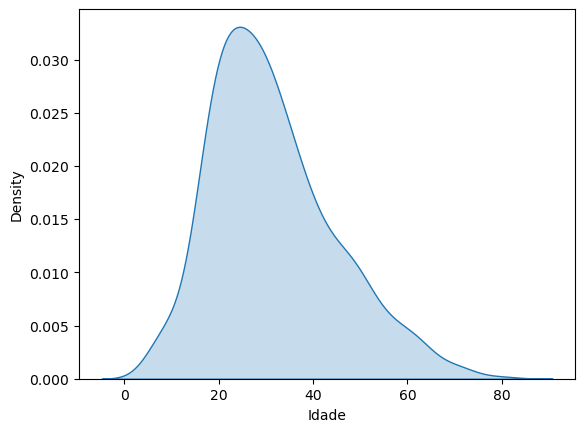

In [38]:
sns.kdeplot(df['Idade'], fill=True)

In [39]:
Q1, Q2, Q3

(np.float64(22.0), np.float64(29.0), np.float64(39.0))

In [40]:
IQ

np.float64(17.0)

<Axes: xlabel='Idade', ylabel='Sexo'>

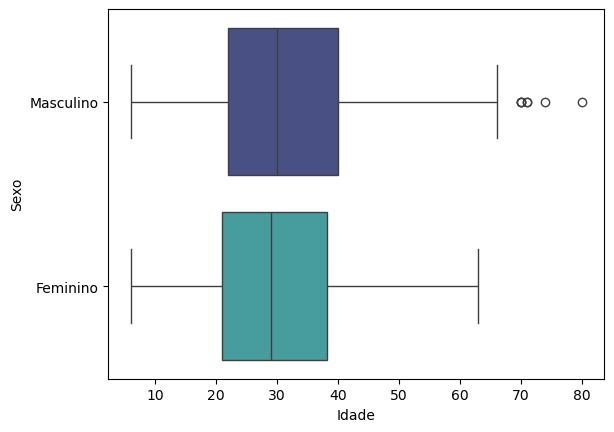

In [41]:
paleta = ['blue', 'red']

sns.boxplot(df, x='Idade', y='Sexo', hue='Sexo', palette='mako')

Text(0.5, 1.0, 'Distribuição de faixa etária')

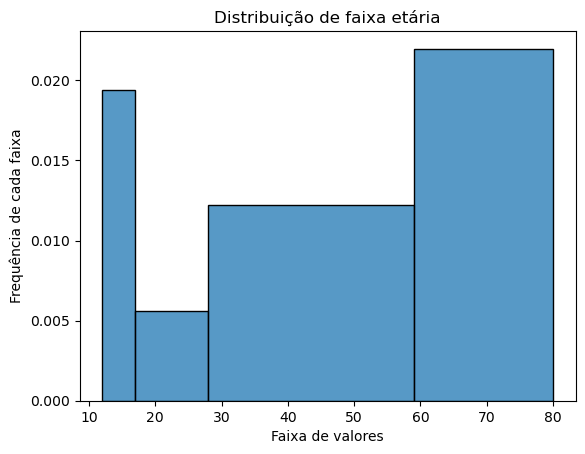

In [42]:
x = [12, 17, 28, 59, 80]
y = [9.7, 6.2, 38.0, 42.6, 3.6]

sns.histplot(x=x, weights=y, stat="density", bins=x, legend='Distribuição de idade')
plt.xlabel('Faixa de valores')
plt.ylabel('Frequência de cada faixa')
plt.title('Distribuição de faixa etária')

([<matplotlib.patches.Wedge at 0x7feb3a6c7cb0>,
 [Text(-0.5118900476346726, 0.9736367798787046, 'Masculino'),
  Text(0.5118903648857771, -0.973636613083704, 'Feminino')])

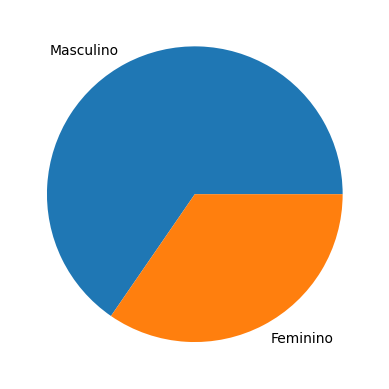

In [43]:
categorias = [len(df.loc[df['Sexo'] == 'Masculino']), len(df.loc[df['Sexo'] == 'Feminino'])]
rotulos = ['Masculino', 'Feminino']
plt.pie(categorias, labels=rotulos)

<Axes: >

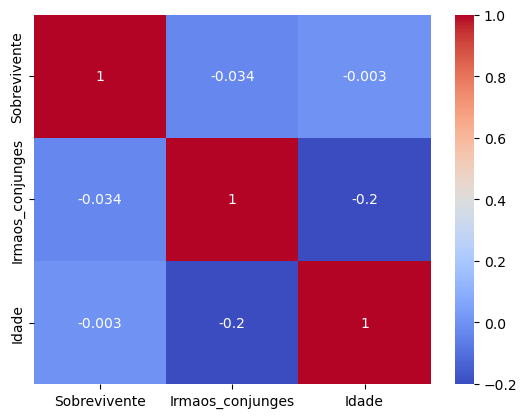

In [44]:
correlacao = df[['Sobrevivente', 'Irmaos_conjunges', 'Idade']].corr()
sns.heatmap(correlacao, annot=True, cmap='coolwarm')